# 2026 FIFA World Cup Predictive Baseline Engine & Live Simulator
**Developer Workspace** This notebook ingests historical international football results, standardizes economic squad values, trains a Predicitve Neural Network to output symmetric match baselines, and spins up an interactive live-match Bayesian tracking matrix.

In [119]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import time
import threading
import re

pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style="whitegrid")

print("Setup done!")

df_matches = pd.read_csv('all_matches.csv')
df_matches['date'] = pd.to_datetime(df_matches['date'])

def determine_outcome(row):
    if row['home_score'] > row['away_score']: return 'H'
    if row['home_score'] < row['away_score']: return 'A'
    return 'D'
df_matches['outcome'] = df_matches.apply(determine_outcome, axis=1)
df_modern = df_matches[df_matches['date'] >= '2000-01-01'].copy()
df_modern['home_goal_diff'] = df_modern['home_score'] - df_modern['away_score']
def assign_match_wt(t):
    t = str(t).lower()
    if 'world cup' in t and ('qual' not in t): return 4
    if ('euro' in t or 'copa america' in t or 'afcon' in t) and ('qual' in t): return 3
    if 'qualifying' in t or 'nations_league' in t: return 2
    return 1
df_modern['match_wt'] = df_modern['tournament'].apply(assign_match_wt)
print(f"Loaded {df_modern.shape} matches from the modern era.") 
df_modern.sample(5)




Setup done!
Loaded (25382, 11) matches from the modern era.


,date,home_team,away_team,home_score,away_score,tournament,country,neutral,outcome,home_goal_diff,match_wt
31353,2005-06-05,Brazil,Paraguay,4.00,1.00,World Cup qualifier,Brazil,False,H,3.00,1
36696,2011-03-25,Maldives,Tajikistan,0.00,0.00,Asian Cup & Asian Chlg Cup q,Maldives,False,D,0.00,1
32891,2007-03-28,Romania,Luxembourg,3.00,0.00,European Championship qual,Romania,False,H,3.00,3
28588,2002-06-17,Brazil,Belgium,2.00,0.00,World Cup,Japan,True,H,2.00,4
31051,2005-02-02,Bahrain,Lebanon,2.00,1.00,Friendly,Qatar,True,H,1.00,1


In [120]:
print("Connection to internation data archive for rolling stats started!")
try:
    url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
    df_raw = pd.read_csv(url)
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    df_recent = df_raw[df_raw['date'] >= '2024-01-01'].copy()
    print(f"Successfully created {df_recent.shape[0]} live metrics from recent cycles.")
except Exception as e:
    print(f"Failed: {e}")
    df_recent = df_modern.copy()

home_stats = df_recent.groupby('home_team').agg(
    MP=('home_score', 'count'), GF=('home_score', 'sum'), GA=('away_score', 'sum'),
    W=('home_score', lambda x: (x > df_recent.loc[x.index, 'away_score']).sum()),
    D=('home_score', lambda x: (x == df_recent.loc[x.index, 'away_score']).sum()),
    L=('home_score', lambda x: (x < df_recent.loc[x.index, 'away_score']).sum())
)

away_stats = df_recent.groupby('away_team').agg(
    MP=('away_score', 'count'), GF=('away_score', 'sum'), GA=('home_score', 'sum'),
    W=('away_score', lambda x: (x > df_recent.loc[x.index, 'home_score']).sum()),
    D=('away_score', lambda x: (x == df_recent.loc[x.index, 'home_score']).sum()),
    L=('away_score', lambda x: (x < df_recent.loc[x.index, 'home_score']).sum())
)

df_global_live = home_stats.add(away_stats, fill_value=0).reset_index().rename(columns={'index': 'Squad'})
df_global_live['goals_scored_per_game'] = df_global_live['GF'] / df_global_live['MP']
df_global_live['goals_conceded_per_game'] = df_global_live['GA'] / df_global_live['MP']
df_global_live['win_ratio'] = df_global_live['W'] / df_global_live['MP']
df_global_live.to_csv('global_teams_profiles.csv', index=False)
print(f"Created baseline for {df_global_live.shape[0]} international squads")
df_global_live.sample(5)

Connection to internation data archive for rolling stats started!
Successfully created 2518 live metrics from recent cycles.
Created baseline for 234 international squads


,Squad,MP,GF,GA,W,D,L,goals_scored_per_game,goals_conceded_per_game,win_ratio
187,Slovakia,27.00,37.00,32.00,13.00,4.00,10.00,1.37,1.19,0.48
149,Nigeria,39.00,64.00,31.00,21.00,14.00,4.00,1.64,0.79,0.54
39,Cayman Islands,14.00,12.00,24.00,5.00,2.00,7.00,0.86,1.71,0.36
162,Peru,24.00,17.00,26.00,5.00,8.00,11.00,0.71,1.08,0.21
104,Ivory Coast,35.00,60.00,23.00,22.00,6.00,7.00,1.71,0.66,0.63


In [121]:
df_custom_wc = pd.read_csv('world_cup_teams.csv')
def convertor(val):
    if pd.isna(val): return 0.0
    val_str = str(val).upper().replace('€','').replace('M','').replace('B','').strip()
    try:
        return float(val_str) * 1000000.0
    except ValueError:
        return 0.0
df_custom_wc['market_value_euros'] = df_custom_wc['market_value_euros'].apply(convertor)
df_custom_wc['average_market_value_euros'] = df_custom_wc['average_market_value_euros'].apply(convertor)
df_master_profiles = pd.merge(df_custom_wc, df_global_live[['Squad', 'goals_scored_per_game', 'goals_conceded_per_game', 'win_ratio']], left_on='club', right_on='Squad', how='inner').drop(columns=['Squad']).rename(columns={'club':  'Squad'})
df_wc_matches = df_modern[df_modern['home_team'].isin(df_master_profiles['Squad']) | df_modern['away_team'].isin(df_master_profiles['Squad'])].copy()

df_final_features = pd.merge(df_wc_matches, df_master_profiles.add_prefix('home_'), left_on='home_team', right_on='home_Squad', how='left').drop(columns=['home_Squad'])
df_final_features = pd.merge(df_final_features, df_master_profiles.add_prefix('away_'), left_on='away_team', right_on='away_Squad', how='left').drop(columns=['away_Squad'])

df_final_features['home_host_indicator'] = ((df_final_features['country'] == df_final_features['home_team']) & (df_final_features['neutral'] == False)).astype(float)
df_final_features['away_host_indicator'] = ((df_final_features['country'] == df_final_features['away_team']) & (df_final_features['neutral'] == False)).astype(float)

fill_baselines = {
    'home_fifa_ranking': 80.0, 'home_average_age': 26.5, 'home_historical_participation': 1.0,
    'home_market_value_euros': 15000000.0, 'home_average_market_value_euros': 600000.0, 'home_squad_size': 25.0,
    'home_fifa_points': 1350.0, 'home_goals_scored_per_game': 1.0, 'home_goals_conceded_per_game': 1.5, 'home_win_ratio': 0.25,
    'away_fifa_ranking': 80.0, 'away_average_age': 26.5, 'away_historical_participation': 1.0,
    'away_market_value_euros': 15000000.0, 'away_average_market_value_euros': 600000.0, 'away_squad_size': 25.0,
    'away_fifa_points': 1350.0, 'away_goals_scored_per_game': 1.0, 'away_goals_conceded_per_game': 1.5, 'away_win_ratio': 0.25
}
df_final_features = df_final_features.fillna(value=fill_baselines)
df_final_features['neutral_flag'] = df_final_features['neutral'].astype(int).astype('float32')
print(f"Feature Array Shape: {df_final_features.shape[0]}")


Feature Array Shape: 12033


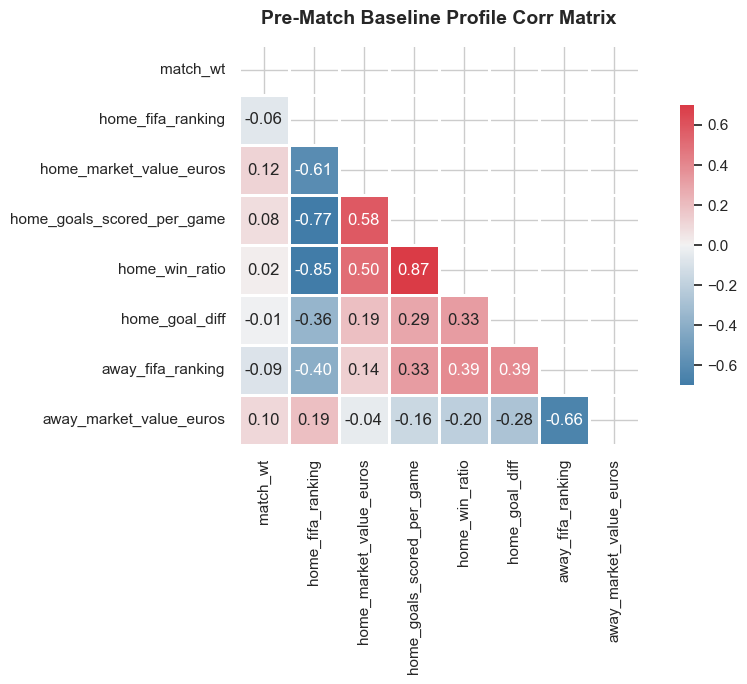

In [122]:
eda_cols = [
    'match_wt', 'home_fifa_ranking', 'home_market_value_euros', 
    'home_goals_scored_per_game', 'home_win_ratio', 'home_goal_diff',
    'away_fifa_ranking', 'away_market_value_euros'
]
plt.figure(figsize=(10,7))
corr_matrix = df_final_features[eda_cols].corr()
triangle_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=triangle_mask,
    cmap=sns.diverging_palette(240, 10, as_cmap=True),
    vmax=.7, vmin=-.7, center=0,
    square=True, linewidths=.8,
    cbar_kws={"shrink": .7},
    annot=True, fmt=".2f"
)
plt.title("Pre-Match Baseline Profile Corr Matrix", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [123]:
split_date = pd.to_datetime('2021-01-01')
df_train = df_final_features[df_final_features['date'] < split_date].copy()
df_test = df_final_features[df_final_features['date'] >= split_date].copy()
for df in [df_train, df_test]:
    df['home_power_score'] = np.exp(-df['home_fifa_ranking'] / 20.0)
    df['away_power_score'] = np.exp(-df['away_fifa_ranking'] / 20.0)
    df['ranking_delta'] = df['home_power_score'] - df['away_power_score']
    df['points_delta'] = df['home_fifa_points'] - df['away_fifa_points']

    df['log_market_value_delta'] = np.log1p(df['home_market_value_euros']) - np.log1p(df['away_market_value_euros'])

    df['win_ratio_delta'] = df['home_win_ratio'] - df['away_win_ratio']
    df['scoring_delta'] = df['home_goals_scored_per_game'] - df['away_goals_conceded_per_game']


outcome_mapping = {'H' : 0, 'D': 1, 'A' : 2}
y_train = df_train['outcome'].map(outcome_mapping)
y_test = df_test['outcome'].map(outcome_mapping)

feature_columns = [
    'match_wt', 'neutral_flag', 'ranking_delta', 'points_delta', 'log_market_value_delta',
    'win_ratio_delta', 'scoring_delta', 'home_host_indicator', 'away_host_indicator'
]

X_train = df_train[feature_columns].astype('float32')
X_test = df_test[feature_columns].astype('float32')

pd.reset_option('display.float_format')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Vector Dimensions: {X_train_scaled.shape[1]}")

Vector Dimensions: 9


In [124]:
model = Sequential([
    Dense(128, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    Dropout(.3),
    
    Dense(64, activation='relu'),
    Dropout(.2),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Neural Network architecture created. Training loop started...")

#minimal training after 50 epochs
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=.2, verbose=1)
print("\n Done!")

Neural Network architecture created. Training loop started...
Epoch 1/50


c:\Users\yashi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


236/236 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5951 - loss: 0.8758 - val_accuracy: 0.6337 - val_loss: 0.8303
Epoch 2/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6082 - loss: 0.8549 - val_accuracy: 0.6326 - val_loss: 0.8330
Epoch 3/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6098 - loss: 0.8496 - val_accuracy: 0.6348 - val_loss: 0.8336
Epoch 4/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6095 - loss: 0.8483 - val_accuracy: 0.6337 - val_loss: 0.8336
Epoch 5/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6110 - loss: 0.8473 - val_accuracy: 0.6326 - val_loss: 0.8320
Epoch 6/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6104 - loss: 0.8440 - val_accuracy: 0.6326 - val_loss: 0.8289
Epoch 7/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6127 - loss: 0.8442 - val_accuracy: 0.6385 - val_loss: 0.8309
Epoch 8/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6112 - loss: 0.8440 - val_accuracy: 0.6385 - val_

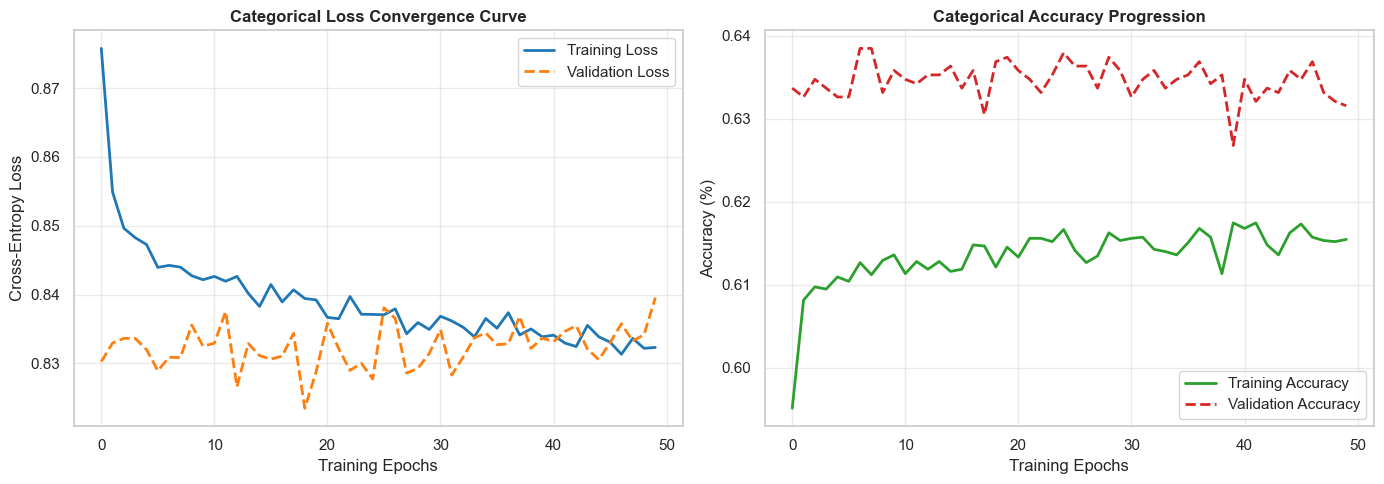

Test Accuracy: 0.6583048105239868 ---- Cross-Entropy Loss: 0.7950311899185181


In [125]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')
ax1.set_title('Categorical Loss Convergence Curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=.4)

ax2.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2, linestyle='--')
ax2.set_title('Categorical Accuracy Progression', fontsize=12, fontweight='bold')
ax2.set_xlabel('Training Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=.4)

plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy} ---- Cross-Entropy Loss: {test_loss}")


In [129]:
df_26 = pd.read_csv('world_cup_26_games.csv')

df_26.rename(columns={'ESPN_ID' : 'espn_id'}, inplace=True)
df_26['neutral_flag'] = df_26['neutral_flag'].astype(float)

df_home_profiles = df_master_profiles.add_prefix('home_')
df_away_profiles = df_master_profiles.add_prefix('away_')

df_pass1 = df_26.merge(df_home_profiles, left_on='home_team', right_on='home_Squad', how='left')
df_pass1 = df_pass1.merge(df_away_profiles, left_on='away_team', right_on='away_Squad', how='left')
df_pass1['match_wt'] = 4.0
df_pass1['neutral_flag'] = 1.0
df_pass1['home_host_indicator'] = 0.0
df_pass1['away_host_indicator'] = 0.0
df_pass1.fillna(fill_baselines, inplace=True)


df_pass1['home_power_score'] = np.exp(-df_pass1['home_fifa_ranking'] / 20.0)
df_pass1['away_power_score'] = np.exp(-df_pass1['away_fifa_ranking'] / 20.0)
df_pass1['ranking_delta'] = df_pass1['home_power_score'] - df_pass1['away_power_score']
df_pass1['points_delta'] = df_pass1['home_fifa_points'] - df_pass1['away_fifa_points']
df_pass1['log_market_value_delta'] = np.log1p(df_pass1['home_market_value_euros']) -np.log1p(df_pass1['away_market_value_euros'])
df_pass1['win_ratio_delta'] = df_pass1['home_win_ratio'] - df_pass1['away_win_ratio']
df_pass1['scoring_delta'] = df_pass1['home_goals_scored_per_game'] - df_pass1['away_goals_conceded_per_game']

X_pass1_scaled = scaler.transform(df_pass1[feature_columns])
preds_pass1 = model.predict(X_pass1_scaled, verbose=1)

df_swapped = df_26.copy()
df_swapped['home_team'] = df_26['away_team']
df_swapped['away_team'] = df_26['home_team']

df_pass2 = df_swapped.merge(df_home_profiles, left_on='home_team', right_on='home_Squad', how='left')
df_pass2 = df_pass2.merge(df_away_profiles, left_on='away_team', right_on='away_Squad', how='left')
df_pass2['match_wt'] = 4.0
df_pass2['neutral_flag'] = 1.0
df_pass2['home_host_indicator'] = 0.0
df_pass2['away_host_indicator'] = 0.0
df_pass2.fillna(fill_baselines, inplace=True)

df_pass2['home_power_score'] = np.exp(-df_pass2['home_fifa_ranking'] / 20.0)
df_pass2['away_power_score'] = np.exp(-df_pass2['away_fifa_ranking'] / 20.0)
df_pass2['ranking_delta'] = df_pass2['home_power_score'] - df_pass2['away_power_score']
df_pass2['points_delta'] = df_pass2['home_fifa_points'] - df_pass2['away_fifa_points']
df_pass2['log_market_value_delta'] = np.log1p(df_pass2['home_market_value_euros']) -np.log1p(df_pass2['away_market_value_euros'])
df_pass2['win_ratio_delta'] = df_pass2['home_win_ratio'] - df_pass2['away_win_ratio']
df_pass2['scoring_delta'] = df_pass2['home_goals_scored_per_game'] - df_pass2['away_goals_conceded_per_game']

X_pass2_scaled = scaler.transform(df_pass2[feature_columns])
preds_pass2 = model.predict(X_pass2_scaled, verbose=1)

avg_home_win = (preds_pass1[:, 0] + preds_pass2[:, 2]) / 2.0
avg_draw = (preds_pass1[:, 1] + preds_pass2[:, 1]) / 2.0
avg_away_win = (preds_pass1[:, 2] + preds_pass2[:, 0]) / 2.0

totals = avg_home_win + avg_draw + avg_away_win
final_home_pct = (avg_home_win / totals) * 100
final_draw_pct = (avg_draw / totals) * 100
final_away_pct = (avg_away_win / totals) * 100

df_26_baselines = pd.DataFrame({
    'Match_ID' : df_26['match_id'].values,
    'Stage': df_26['stage'].values,
    'Home Team' : df_26['home_team'].values,
    'Away Team': df_26['away_team'].values,
    'ESPN_ID': df_26['espn_id'].values,
    'Pre_Home_Win_Pct' : final_home_pct.round(2),
    'Pre_Draw_Pct' : final_draw_pct.round(2),
    'Pre_Away_Win_Pct' : final_away_pct.round(2)
})

df_26_baselines.to_csv('world_cup_26_baselines.csv', index=False)
print("Baselines computed and csv created")
df_26_baselines.sample(5) 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Baselines computed and csv created


,Match_ID,Stage,Home Team,Away Team,ESPN_ID,Pre_Home_Win_Pct,Pre_Draw_Pct,Pre_Away_Win_Pct
36,37,Group H,Spain,Saudi Arabia,760453,45.790001,29.590000,24.620001
67,68,Group L,Panama,England,760485,32.509998,45.290001,22.209999
33,34,Group E,Germany,Ivory Coast,760448,42.680000,29.500000,27.820000
88,89,Round of 16,Round of 32 1 Winner,Round of 32 3 Winner,760502,36.939999,26.110001,36.939999
2,3,Group B,Canada,Bosnia and Herzegovina,760416,40.950001,26.120001,32.930000
